# Reusable Transportation Optimization Agent

## Goal

This Colab-ready notebook turns transportation data into a validated linear-programming model, solves it with CBC or HiGHS, explains feasibility and cost, and exports an Excel workbook plus a network diagram.

**Workflow:** define or import inputs â†’ validate â†’ formulate LP â†’ solve â†’ verify â†’ export.

The mathematical solverâ€”not a language modelâ€”determines feasibility and the optimum. An AI assistant can use the reusable prompt near the end to collect requirements and adapt the Python interface without inventing results.

## Setup

Run this once per Colab session. Missing packages are installed automatically.

In [1]:
import importlib.metadata
import importlib.util
import os
import subprocess
import sys
import tempfile
from pathlib import Path

matplotlib_config = Path(tempfile.gettempdir()) / "transportation_agent_matplotlib"
matplotlib_config.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(matplotlib_config))

packages = {
    "highspy": "highspy",
    "pandas": "pandas",
    "openpyxl": "openpyxl",
    "networkx": "networkx",
    "matplotlib": "matplotlib",
}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if importlib.util.find_spec("pulp") is None:
    missing.append("pulp<4")
elif int(importlib.metadata.version("pulp").split(".")[0]) >= 4:
    missing.append("pulp<4")
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *missing])

print("Optimization environment is ready.")

Optimization environment is ready.


In [2]:
from dataclasses import dataclass
from math import isfinite
from pathlib import Path
from typing import Dict, Optional, Tuple

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import pulp
from IPython.display import Image, display

RouteKey = Tuple[str, str]
TOLERANCE = 1e-7

## Step 1 â€” Define and validate the problem

Supply constraints are upper bounds, customer demand must be met exactly, unavailable routes are omitted, and optional route capacities are enforced.

In [3]:
@dataclass(frozen=True)
class Route:
    cost: float
    capacity: Optional[float] = None


@dataclass(frozen=True)
class TransportationProblem:
    supplier_capacities: Dict[str, float]
    customer_demands: Dict[str, float]
    routes: Dict[RouteKey, Route]
    name: str = "Transportation Problem"

    def validate(self) -> None:
        if not self.supplier_capacities:
            raise ValueError("At least one supplier is required.")
        if not self.customer_demands:
            raise ValueError("At least one customer is required.")
        if not self.routes:
            raise ValueError("At least one available route is required.")

        for supplier, capacity in self.supplier_capacities.items():
            if not supplier or not isfinite(float(capacity)) or capacity < 0:
                raise ValueError(f"Invalid capacity for supplier {supplier!r}: {capacity}")

        for customer, demand in self.customer_demands.items():
            if not customer or not isfinite(float(demand)) or demand < 0:
                raise ValueError(f"Invalid demand for customer {customer!r}: {demand}")

        for (supplier, customer), route in self.routes.items():
            if supplier not in self.supplier_capacities:
                raise ValueError(f"Route references unknown supplier {supplier!r}.")
            if customer not in self.customer_demands:
                raise ValueError(f"Route references unknown customer {customer!r}.")
            if not isfinite(float(route.cost)):
                raise ValueError(f"Route {supplier}->{customer} has an invalid cost.")
            if route.capacity is not None and (
                not isfinite(float(route.capacity)) or route.capacity < 0
            ):
                raise ValueError(f"Route {supplier}->{customer} has an invalid capacity.")

        disconnected = [
            customer
            for customer, demand in self.customer_demands.items()
            if demand > 0 and not any(c == customer for _, c in self.routes)
        ]
        if disconnected:
            raise ValueError(f"No available inbound route for: {', '.join(disconnected)}")

## Step 2 â€” Formulate and solve the linear program

The objective minimizes total shipping cost. The returned tables keep zero-flow routes for auditing.

In [4]:
def solve_transportation(
    problem: TransportationProblem,
    solver_name: str = "CBC",
    show_solver_log: bool = False,
) -> dict:
    problem.validate()
    model = pulp.LpProblem("_".join(problem.name.split()), pulp.LpMinimize)

    shipment = {
        key: pulp.LpVariable(
            f"ship_{key[0]}_{key[1]}",
            lowBound=0,
            upBound=route.capacity,
            cat="Continuous",
        )
        for key, route in problem.routes.items()
    }

    model += pulp.lpSum(
        problem.routes[key].cost * variable for key, variable in shipment.items()
    ), "Total_Transportation_Cost"

    for supplier, capacity in problem.supplier_capacities.items():
        model += (
            pulp.lpSum(variable for (s, _), variable in shipment.items() if s == supplier)
            <= capacity,
            f"Capacity_{supplier}",
        )

    for customer, demand in problem.customer_demands.items():
        model += (
            pulp.lpSum(variable for (_, c), variable in shipment.items() if c == customer)
            == demand,
            f"Demand_{customer}",
        )

    normalized_solver = solver_name.strip().upper()
    if normalized_solver == "CBC":
        solver = pulp.PULP_CBC_CMD(msg=show_solver_log)
    elif normalized_solver == "HIGHS":
        solver = pulp.HiGHS(msg=show_solver_log)
    else:
        raise ValueError("solver_name must be 'CBC' or 'HiGHS'.")

    model.solve(solver)
    status = pulp.LpStatus[model.status]
    feasible = status == "Optimal"

    route_rows = []
    for (supplier, customer), route in problem.routes.items():
        quantity = float(shipment[(supplier, customer)].varValue or 0) if feasible else 0.0
        route_rows.append(
            {
                "Supplier": supplier,
                "Customer": customer,
                "Quantity": quantity,
                "Unit Cost": float(route.cost),
                "Route Capacity": route.capacity,
                "Route Cost": quantity * float(route.cost),
            }
        )
    shipments = pd.DataFrame(route_rows)

    supplier_rows = []
    for supplier, capacity in problem.supplier_capacities.items():
        shipped = float(shipments.loc[shipments["Supplier"] == supplier, "Quantity"].sum())
        supplier_rows.append(
            {
                "Supplier": supplier,
                "Capacity": float(capacity),
                "Shipped": shipped,
                "Unused Capacity": float(capacity) - shipped,
            }
        )

    customer_rows = []
    for customer, demand in problem.customer_demands.items():
        received = float(shipments.loc[shipments["Customer"] == customer, "Quantity"].sum())
        customer_rows.append(
            {
                "Customer": customer,
                "Demand": float(demand),
                "Received": received,
                "Demand Difference": received - float(demand),
            }
        )

    total_cost = float(pulp.value(model.objective)) if feasible else None
    result = {
        "problem": problem,
        "model": model,
        "status": status,
        "feasible": feasible,
        "solver": normalized_solver,
        "total_cost": total_cost,
        "shipments": shipments,
        "supplier_summary": pd.DataFrame(supplier_rows),
        "customer_summary": pd.DataFrame(customer_rows),
    }
    return result

## Step 3 â€” Explain, verify, and export

The agent checks conservation constraints independently after solving. It writes transparent input and result tables to Excel and draws only positive-flow routes in the network image.

In [5]:
def verify_solution(result: dict, tolerance: float = 1e-6) -> None:
    if not result["feasible"]:
        return
    suppliers_ok = (result["supplier_summary"]["Unused Capacity"] >= -tolerance).all()
    customers_ok = (result["customer_summary"]["Demand Difference"].abs() <= tolerance).all()
    routes = result["shipments"]
    route_caps_ok = (
        routes["Route Capacity"].isna()
        | (routes["Quantity"] <= routes["Route Capacity"].astype(float) + tolerance)
    ).all()
    nonnegative_ok = (routes["Quantity"] >= -tolerance).all()
    if not (suppliers_ok and customers_ok and route_caps_ok and nonnegative_ok):
        raise AssertionError("The returned solution failed an independent constraint check.")


def explain_solution(result: dict) -> str:
    problem = result["problem"]
    total_supply = sum(problem.supplier_capacities.values())
    total_demand = sum(problem.customer_demands.values())
    if not result["feasible"]:
        return (
            f"No feasible solution was found (solver status: {result['status']}). "
            f"Total capacity is {total_supply:g} and total demand is {total_demand:g}; "
            "route availability or route capacities may still prevent demand fulfillment."
        )

    used = result["shipments"].loc[result["shipments"]["Quantity"] > TOLERANCE]
    route_text = "; ".join(
        f"{row.Supplier} -> {row.Customer}: {row.Quantity:g} units"
        for row in used.itertuples(index=False)
    )
    unused = float(result["supplier_summary"]["Unused Capacity"].sum())
    return (
        f"A feasible optimal solution exists. Ship {route_text}. "
        f"All {total_demand:g} units of demand are satisfied, {unused:g} units of capacity "
        f"remain unused, and the minimum total cost is ${result['total_cost']:,.2f}."
    )


def export_excel(result: dict, path: Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    problem = result["problem"]
    suppliers = pd.DataFrame(
        [{"Supplier": key, "Capacity": value} for key, value in problem.supplier_capacities.items()]
    )
    customers = pd.DataFrame(
        [{"Customer": key, "Demand": value} for key, value in problem.customer_demands.items()]
    )
    routes = pd.DataFrame(
        [
            {
                "Supplier": supplier,
                "Customer": customer,
                "Cost": route.cost,
                "Route Capacity": route.capacity,
            }
            for (supplier, customer), route in problem.routes.items()
        ]
    )
    summary = pd.DataFrame(
        [
            {"Metric": "Status", "Value": result["status"]},
            {"Metric": "Solver", "Value": result["solver"]},
            {"Metric": "Total Cost", "Value": result["total_cost"]},
            {"Metric": "Explanation", "Value": explain_solution(result)},
        ]
    )

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        summary.to_excel(writer, sheet_name="Summary", index=False)
        suppliers.to_excel(writer, sheet_name="Input Suppliers", index=False)
        customers.to_excel(writer, sheet_name="Input Customers", index=False)
        routes.to_excel(writer, sheet_name="Input Routes", index=False)
        result["shipments"].to_excel(writer, sheet_name="Shipments", index=False)
        result["supplier_summary"].to_excel(writer, sheet_name="Supplier Summary", index=False)
        result["customer_summary"].to_excel(writer, sheet_name="Customer Summary", index=False)

        for worksheet in writer.book.worksheets:
            worksheet.freeze_panes = "A2"
            worksheet.auto_filter.ref = worksheet.dimensions
            for column_cells in worksheet.columns:
                width = min(60, max(len(str(cell.value or "")) for cell in column_cells) + 2)
                worksheet.column_dimensions[column_cells[0].column_letter].width = width
    return path.resolve()


def export_network(result: dict, path: Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    problem = result["problem"]
    graph = nx.DiGraph()
    suppliers = list(problem.supplier_capacities)
    customers = list(problem.customer_demands)
    graph.add_nodes_from(suppliers, kind="supplier")
    graph.add_nodes_from(customers, kind="customer")

    used = result["shipments"].loc[result["shipments"]["Quantity"] > TOLERANCE]
    for _, row in used.iterrows():
        graph.add_edge(
            row["Supplier"],
            row["Customer"],
            quantity=row["Quantity"],
            unit_cost=row["Unit Cost"],
        )

    supplier_y = list(reversed(range(len(suppliers))))
    customer_y = list(reversed(range(len(customers))))
    positions = {supplier: (0, y) for supplier, y in zip(suppliers, supplier_y)}
    positions.update({customer: (1, y) for customer, y in zip(customers, customer_y)})

    fig, ax = plt.subplots(figsize=(10, max(5, 1.2 * max(len(suppliers), len(customers)))))
    nx.draw_networkx_nodes(
        graph, positions, nodelist=suppliers, node_color="#2F6B9A", node_size=1900, ax=ax
    )
    nx.draw_networkx_nodes(
        graph, positions, nodelist=customers, node_color="#E69F00", node_size=1900, ax=ax
    )
    nx.draw_networkx_labels(graph, positions, font_color="white", font_weight="bold", ax=ax)
    nx.draw_networkx_edges(
        graph, positions, width=2, edge_color="#4D4D4D", arrows=True, arrowsize=20, ax=ax
    )
    for edge_index, (source, target, data) in enumerate(graph.edges(data=True)):
        x0, y0 = positions[source]
        x1, y1 = positions[target]
        fraction = 0.36 if edge_index % 2 == 0 else 0.64
        ax.text(
            x0 + fraction * (x1 - x0),
            y0 + fraction * (y1 - y0),
            f"{data['quantity']:g} @ ${data['unit_cost']:g}",
            fontsize=9,
            ha="center",
            va="center",
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.5},
        )
    ax.set_title(f"{problem.name}: Optimal Positive-Flow Routes", fontsize=13, fontweight="bold")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return path.resolve()

In [6]:
class TransportationOptimizationAgent:
    'Reusable deterministic agent for validation, solving, verification, and exports.'

    def __init__(self, solver_name: str = "CBC"):
        self.solver_name = solver_name

    def run(self, problem: TransportationProblem, output_dir: Path = Path("transportation_outputs")) -> dict:
        result = solve_transportation(problem, solver_name=self.solver_name)
        verify_solution(result)
        result["explanation"] = explain_solution(result)

        if result["feasible"]:
            output_dir = Path(output_dir)
            safe_name = "_".join(problem.name.split())
            result["excel_path"] = export_excel(result, output_dir / f"{safe_name}_Solution.xlsx")
            result["network_path"] = export_network(result, output_dir / f"{safe_name}_Network.png")
        return result

## Step 4 â€” Run the supplied example

Unavailable routes `S1 â†’ D3` and `S2 â†’ D2` are omitted from `routes`. A blank route capacity is represented by `None`.

In [7]:
example_problem = TransportationProblem(
    name="Homework Transportation Problem",
    supplier_capacities={"S1": 12, "S2": 17, "S3": 13},
    customer_demands={"D1": 12, "D2": 15, "D3": 8},
    routes={
        ("S1", "D1"): Route(cost=2),
        ("S1", "D2"): Route(cost=6),
        ("S2", "D1"): Route(cost=2),
        ("S2", "D3"): Route(cost=2),
        ("S3", "D1"): Route(cost=4),
        ("S3", "D2"): Route(cost=6),
        ("S3", "D3"): Route(cost=1),
    },
)

agent = TransportationOptimizationAgent(solver_name="CBC")
result = agent.run(example_problem)
print(result["explanation"])
display(result["shipments"].loc[result["shipments"]["Quantity"] > TOLERANCE])

A feasible optimal solution exists. Ship S1 -> D1: 2 units; S1 -> D2: 10 units; S2 -> D1: 10 units; S3 -> D2: 5 units; S3 -> D3: 8 units. All 35 units of demand are satisfied, 7 units of capacity remain unused, and the minimum total cost is $122.00.


,Supplier,Customer,Quantity,Unit Cost,Route Capacity,Route Cost
0,S1,D1,2.0,2.0,None,4.0
1,S1,D2,10.0,6.0,None,60.0
2,S2,D1,10.0,2.0,None,20.0
5,S3,D2,5.0,6.0,None,30.0
6,S3,D3,8.0,1.0,None,8.0


Verified optimum: $122.00
Excel workbook: C:\Users\dylmo\Documents\Codex\2026-09-30\from-google-colab-import-drive-drive\outputs\transportation_outputs\Homework_Transportation_Problem_Solution.xlsx
Network image: C:\Users\dylmo\Documents\Codex\2026-09-30\from-google-colab-import-drive-drive\outputs\transportation_outputs\Homework_Transportation_Problem_Network.png


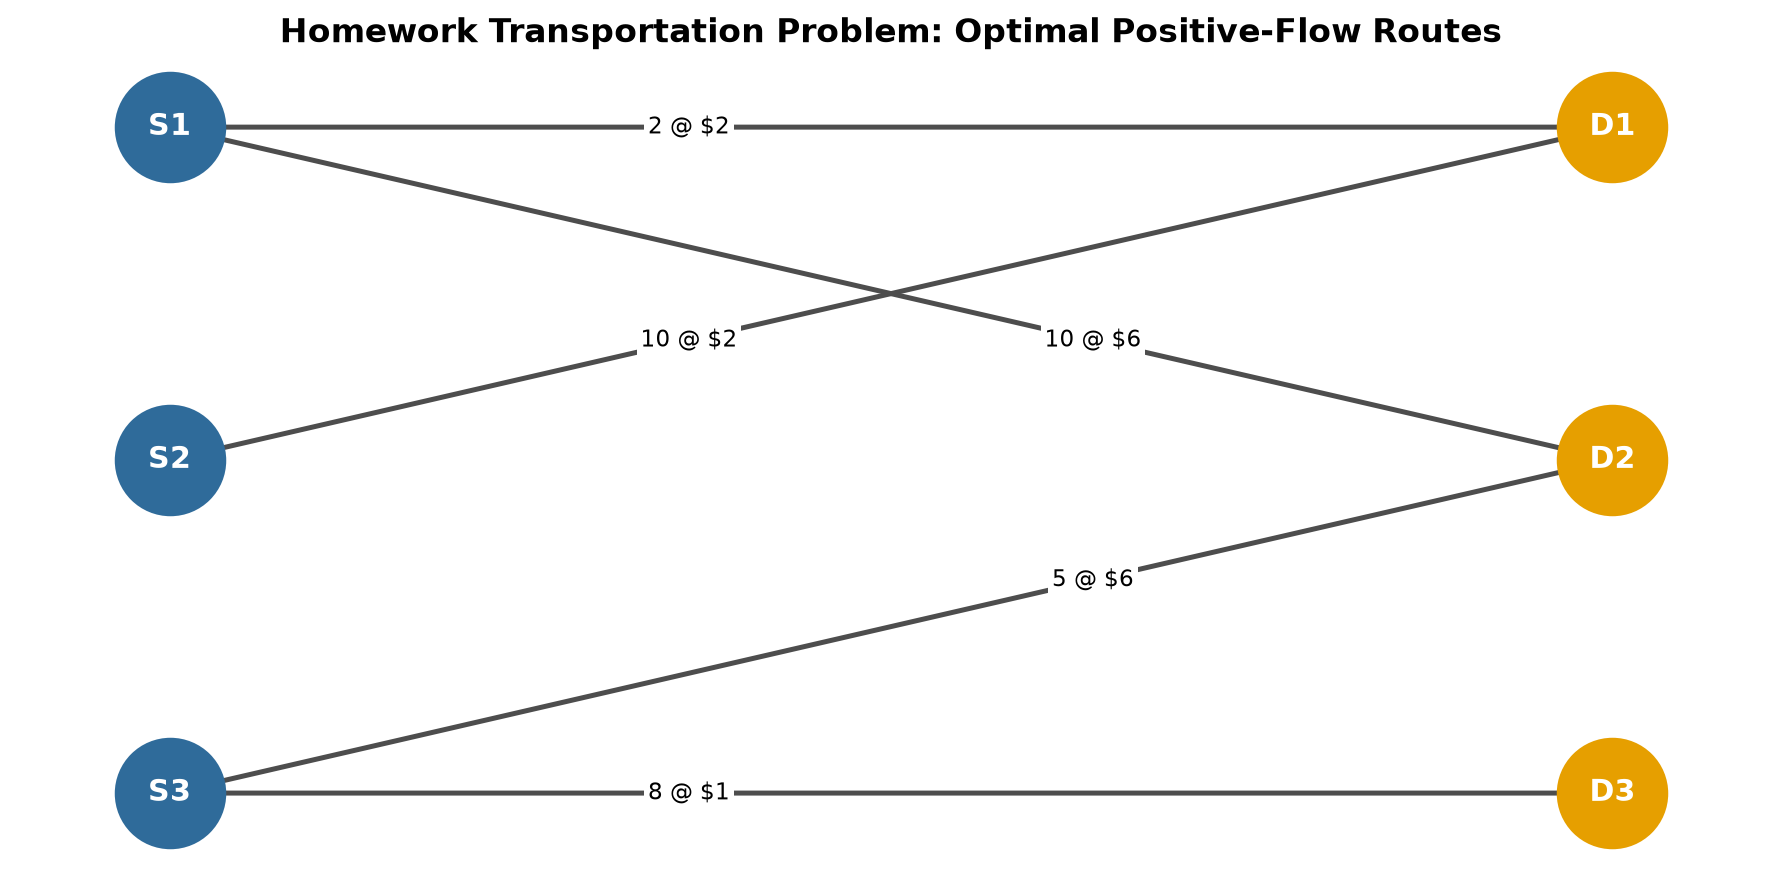

In [8]:
# Independent regression checks for the supplied case.
assert result["status"] == "Optimal"
assert abs(result["total_cost"] - 122.0) <= 1e-6
assert abs(result["customer_summary"]["Demand Difference"].abs().sum()) <= 1e-6
assert abs(result["supplier_summary"]["Unused Capacity"].sum() - 7.0) <= 1e-6

print(f"Verified optimum: ${result['total_cost']:,.2f}")
print(f"Excel workbook: {result['excel_path']}")
print(f"Network image: {result['network_path']}")
display(Image(filename=str(result["network_path"])))

## Step 5 â€” Import a new problem from Excel

The workbook must contain these sheets:

- `Input Suppliers`: `Supplier`, `Capacity`
- `Input Customers`: `Customer`, `Demand`
- `Input Routes`: `Supplier`, `Customer`, `Cost`, and optional `Route Capacity`

Use `NA` or leave the cost blank to exclude a route.

In [9]:
def problem_from_excel(path: Path, name: Optional[str] = None) -> TransportationProblem:
    path = Path(path)
    suppliers = pd.read_excel(path, sheet_name="Input Suppliers")
    customers = pd.read_excel(path, sheet_name="Input Customers")
    routes_frame = pd.read_excel(path, sheet_name="Input Routes")

    supplier_capacities = dict(zip(suppliers["Supplier"].astype(str), suppliers["Capacity"]))
    customer_demands = dict(zip(customers["Customer"].astype(str), customers["Demand"]))
    routes = {}
    for _, row in routes_frame.iterrows():
        cost = row["Cost"]
        if pd.isna(cost) or str(cost).strip().upper() == "NA":
            continue
        capacity = row.get("Route Capacity")
        capacity = None if pd.isna(capacity) else float(capacity)
        routes[(str(row["Supplier"]), str(row["Customer"]))] = Route(float(cost), capacity)

    problem = TransportationProblem(
        name=name or path.stem,
        supplier_capacities=supplier_capacities,
        customer_demands=customer_demands,
        routes=routes,
    )
    problem.validate()
    return problem


# Example for a future workbook:
# new_problem = problem_from_excel("Transportation_Input.xlsx")
# new_result = TransportationOptimizationAgent("HiGHS").run(new_problem)
# print(new_result["explanation"])

## Step 6 â€” Optional interactive input

This helper recreates the question-and-answer workflow. Press Enter for an unlimited route capacity and enter `NA` for an unavailable route.

In [10]:
def _read_nonnegative_number(prompt: str, allow_blank: bool = False) -> Optional[float]:
    while True:
        text = input(prompt).strip()
        if allow_blank and text == "":
            return None
        try:
            value = float(text)
            if value < 0:
                raise ValueError
            return value
        except ValueError:
            print("Enter a nonnegative number" + (" or leave blank" if allow_blank else "") + ".")


def collect_problem_interactively() -> TransportationProblem:
    supplier_count = int(_read_nonnegative_number("Number of suppliers: "))
    customer_count = int(_read_nonnegative_number("Number of customers: "))
    suppliers = [f"S{i}" for i in range(1, supplier_count + 1)]
    customers = [f"D{i}" for i in range(1, customer_count + 1)]

    capacities = {
        supplier: _read_nonnegative_number(f"{supplier} maximum capacity: ")
        for supplier in suppliers
    }
    demands = {
        customer: _read_nonnegative_number(f"{customer} demand: ")
        for customer in customers
    }

    routes = {}
    for supplier in suppliers:
        print(f"\nRoutes from {supplier}")
        for customer in customers:
            while True:
                text = input(f"Cost {supplier} -> {customer} (NA if unavailable): ").strip()
                if text.upper() == "NA":
                    break
                try:
                    cost = float(text)
                    capacity = _read_nonnegative_number(
                        f"Route capacity {supplier}->{customer} (blank=unlimited): ",
                        allow_blank=True,
                    )
                    routes[(supplier, customer)] = Route(cost=cost, capacity=capacity)
                    break
                except ValueError:
                    print("Enter a numeric cost or NA.")

    return TransportationProblem(capacities, demands, routes, name="Interactive Transportation Problem")


# Uncomment these lines to use the interactive workflow:
# interactive_problem = collect_problem_interactively()
# interactive_result = TransportationOptimizationAgent("CBC").run(interactive_problem)
# print(interactive_result["explanation"])

## Reusable AI-agent prompt

Paste the following instructions into an AI assistant when you want it to adapt this notebook or generate a new transportation model:

> You are a transportation linear-programming development agent. Collect supplier names and maximum capacities, customer names and exact demands, available routes and per-unit costs, optional route capacities, solver preference, and desired output location. Treat `NA` routes as unavailable. Never infer missing numeric inputs. Validate nonnegative finite values and known labels. Build the model with nonnegative continuous shipment variables, supplier shipment less than or equal to capacity, customer receipts equal to demand, and route-capacity bounds. Minimize total shipping cost using PuLP with CBC or HiGHS. Report solver status before interpreting variables. Independently verify all constraints and recompute total cost. If infeasible, explain that aggregate capacity alone is not sufficient and identify likely route bottlenecks without inventing an optimum. If optimal, show positive-flow routes, unused supplier capacity, fulfilled customer demand, and total cost. Export inputs and results to a formatted Excel workbook and create a labeled network diagram. Keep paths quoted and use normal underscores rather than escaped underscores.

### Operational guardrails

- Let CBC or HiGHS calculate the solution; do not ask an LLM to perform optimization arithmetic.
- Do not report variable values unless solver status is `Optimal`.
- Keep the input tables in the exported workbook so results remain auditable.
- Run the verification checks whenever the code, data, or solver changes.

## Checks and next steps

The supplied regression test confirms feasibility, a minimum cost of **$122**, exact satisfaction of all **35** demand units, and **7** units of unused supplier capacity. For a new case, replace `example_problem`, import an Excel workbook, or run the interactive helper.

Potential extensions include fixed-charge routes, integer shipments, multiple products, supplier minimums, customer shortages with penalties, emissions limits, and scenario comparison.